# Moment-ETAS on California

Drive the model with a **real gridded moment-rate map** of California as the tectonic loading
field `Ṁ_load(x, y)`. Each grid cell loads at its observed moment rate; the model then decides,
cell by cell, how big and how often earthquakes can occur. The fun result: seismicity (and
especially the large events) concentrates on the high-moment-rate fault systems — the San Andreas
trend and the Eastern California shear zone emerge from the loading map alone.

The moment rate comes in **two components on the same grid**: on-fault (`fault_moment_rates.xyz`)
and off-fault / distributed (`gridded_moment_rates.xyz`), each as `lon  lat  log10(moment rate
[N·m/yr per 0.1° cell])`, NaN where absent. The total loading is their sum — added in **linear
(rate) space**, `10^on + 10^off`, *not* by adding the logs. See `../spec.md` for the model.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.interpolate import RegularGridInterpolator

from moment_etas import Params, simulate_catalog
from moment_etas.visualization import plots

FAULT_PATH = "../data/fault_moment_rates.xyz"      # on-fault component
OFFFAULT_PATH = "../data/gridded_moment_rates.xyz"  # off-fault / distributed component

## 1. Load and combine the moment-rate components

Both files share the same (lat, lon) grid. We exponentiate each to a per-cell rate, **add the two
rates** (NaN → 0 contribution), then convert `log10(per-cell moment rate)` to a **density**
(N·m/km²/yr) by dividing by each cell's area (which shrinks with latitude). Density is the
resolution-independent quantity, so it is what we regrid and feed the model. Ocean (both NaN) → 0.

on-fault defined on 15% of cells; total density combines both components


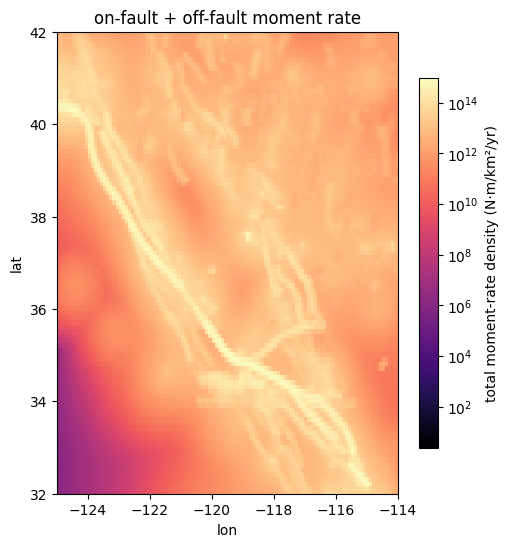

In [2]:
def load_grid(path):
    d = np.loadtxt(path)
    lon, lat = np.unique(d[:, 0]), np.unique(d[:, 1])
    return lon, lat, d[:, 2].reshape(len(lat), len(lon))   # [ilat, ilon], both ascending

lon, lat, V_fault = load_grid(FAULT_PATH)
_, _, V_off = load_grid(OFFFAULT_PATH)

# total moment rate = on-fault + off-fault, summed in LINEAR space (NaN -> 0 contribution)
rate_yr = np.nan_to_num(10.0 ** V_fault) + np.nan_to_num(10.0 ** V_off)   # N·m/yr per 0.1° cell
cell_km2 = (110.57 * 0.1) * (111.32 * np.cos(np.deg2rad(lat))[:, None] * 0.1)
dens_yr = np.where(rate_yr > 0, rate_yr / cell_km2, 0.0)                   # N·m/km²/yr

frac_fault = np.isfinite(V_fault).mean()
print(f"on-fault defined on {frac_fault:.0%} of cells; total density combines both components")

fig, ax = plt.subplots(figsize=(5.5, 6))
im = ax.imshow(np.where(dens_yr > 0, dens_yr, np.nan),
               origin="lower", extent=(lon.min(), lon.max(), lat.min(), lat.max()),
               cmap="magma", norm=LogNorm(), aspect="auto")
plt.colorbar(im, ax=ax, label="total moment-rate density (N·m/km²/yr)", shrink=0.8)
ax.set(xlabel="lon", ylabel="lat", title="on-fault + off-fault moment rate")
ax.set_xlim(-125, -114); ax.set_ylim(32, 42);   # zoom to California

## 2. Regrid onto the model's km grid

Project a California box to local km (equirectangular about the box center), sample the density
onto a uniform `cell`-km grid (nearest-neighbour — the model grid ≈ the native 0.1° ≈ 11 km
resolution), and convert to per-day. The model array is indexed `mdot[i, j]` with `i` along
longitude (x, east) and `j` along latitude (y, north).

In [3]:
lo0, lo1, la0, la1 = -125, -114, 32, 42          # California box
latc = 0.5 * (la0 + la1)
kx = 111.32 * np.cos(np.deg2rad(latc))           # km per degree lon
ky = 110.57                                      # km per degree lat
cell = 10.0                                       # model cell size, km (~ native resolution)
nx = int(round((lo1 - lo0) * kx / cell))
ny = int(round((la1 - la0) * ky / cell))
lx, ly = nx * cell, ny * cell

interp = RegularGridInterpolator((lat, lon), dens_yr, method="nearest",
                                 bounds_error=False, fill_value=0.0)
xi = (np.arange(nx) + 0.5) * cell
yj = (np.arange(ny) + 0.5) * cell
LON = np.broadcast_to(lo0 + xi[:, None] / kx, (nx, ny))
LAT = np.broadcast_to(la0 + yj[None, :] / ky, (nx, ny))
mdot = interp((LAT, LON)) / 365.25               # (nx, ny), per day

print(f"model grid {nx}×{ny}  ({lx:.0f}×{ly:.0f} km),  cell {cell:.0f} km")
print(f"loading per day — peak {mdot.max():.2e},  median(active) {np.median(mdot[mdot>0]):.2e}")
print(f"active (loaded) cells: {(mdot > 0).mean():.0%}")

model grid 98×111  (980×1110 km),  cell 10 km
loading per day — peak 2.61e+12,  median(active) 1.42e+10
active (loaded) cells: 100%


## 3. Run the model

`mdot` is the total California loading map. We **pre-charge** the initial field proportional to
local loading — `F₀ = Ṁ · T_precharge` — i.e. every cell has already been charging at its own rate
for `T_precharge` years (a natural warm start that skips the cold-start burn-in). The physical
loading magnitudes are used directly: the most active fault cells reach M6-supporting budgets in
decades, while the interior stays slow.

In [4]:
precharge_yr = 400.0
params = Params(
    lx=lx, ly=ly, cell=cell,
    mdot=mdot,
    f0=mdot * precharge_yr * 365.25,
    mu0=1e-7,            # background events / day / km² (CA box is ~10^6 km²)
    k=0.05,
)
cat = simulate_catalog(params, t_max=300 * 365.25, seed=1)

print(f"{len(cat)} events, {cat.n_locked} locked discards, largest M{cat.m.max():.1f}")
# do larger events prefer high-loading ground?
ix = np.clip((cat.x / cell).astype(int), 0, nx - 1)
iy = np.clip((cat.y / cell).astype(int), 0, ny - 1)
big = cat.m >= 5.0
print(f"M≥5: {big.sum()} events at {mdot[ix[big], iy[big]].mean() / mdot[mdot>0].mean():.1f}× "
      f"the mean loading")

15402 events, 624 locked discards, largest M6.2
M≥5: 115 events at 1.8× the mean loading


## 4. Where do earthquakes happen?

Epicenters over the loading map (log grey). Small events are everywhere the field can support
them; the large events (red, sized by magnitude) lock onto the high-moment-rate fault systems —
the San Andreas trend and the Eastern California shear zone fall out of the loading map alone.

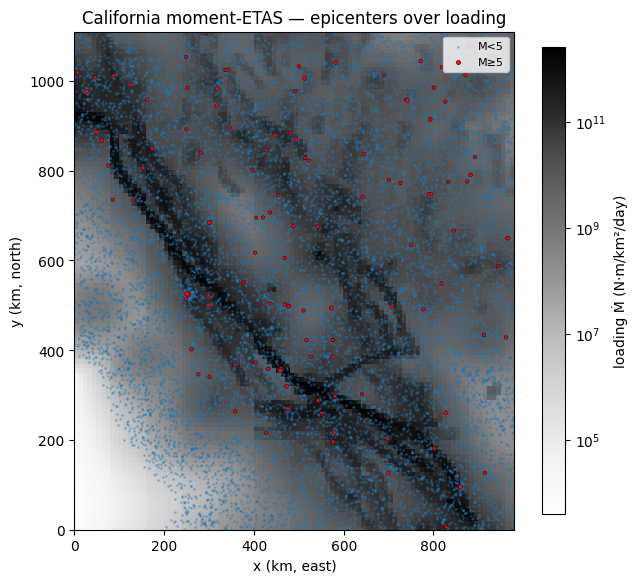

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 7))
im = ax.imshow(np.where(mdot > 0, mdot, np.nan).T, origin="lower",
               extent=(0, lx, 0, ly), cmap="Greys", norm=LogNorm())
plt.colorbar(im, ax=ax, label="loading Ṁ (N·m/km²/day)", shrink=0.7)
ax.scatter(cat.x[~big], cat.y[~big], s=1, c="tab:blue", alpha=0.3, label="M<5")
ax.scatter(cat.x[big], cat.y[big], s=6 * 2 ** (cat.m[big] - 5), c="red",
           edgecolor="k", lw=0.3, label="M≥5")
ax.set(xlabel="x (km, east)", ylabel="y (km, north)",
       title="California moment-ETAS — epicenters over loading", aspect="equal")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()

## 5. Supportable Mmax and magnitude-frequency

Left: the supportable-Mmax map at the end of the run — high where loading (and the charged field)
is high. Right: the pooled magnitude-frequency, against the input GR slope.

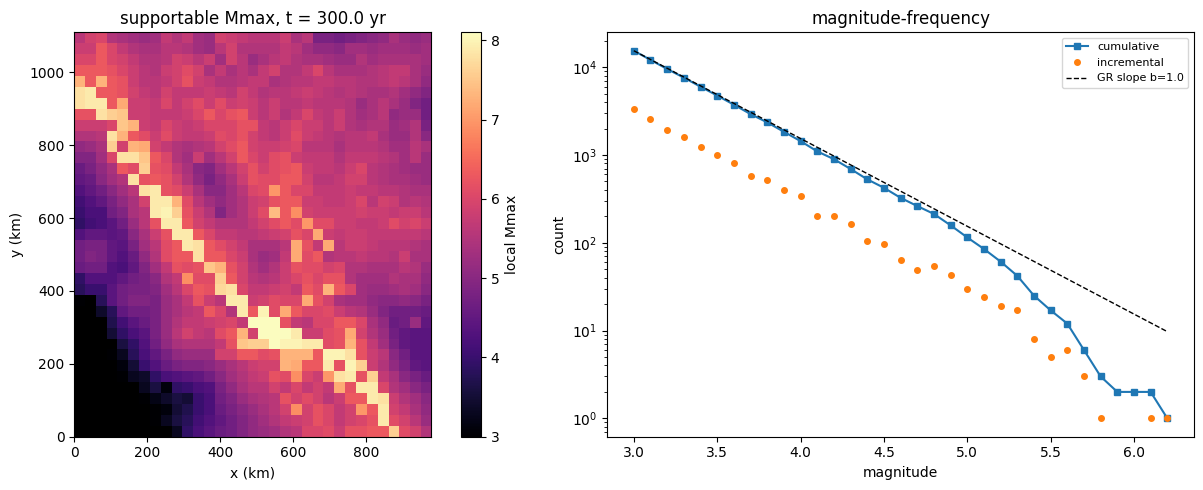

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plots.mmax_map(cat, coarse=3, ax=axes[0])
plots.magnitude_distribution(cat, ax=axes[1])
fig.tight_layout()

## Caveats

- **Combining the components**: the two files are summed as *rates* (`10^on + 10^off`), not by
  adding the log values. On-fault is defined on ~15% of cells and is the dominant contribution
  there.
- **Units / scale**: values are read as `log10(N·m/yr per 0.1° cell)`. If the source convention
  differs, rescale `rate_yr` — the spatial *pattern* is the robust part.
- **Resolution**: at `cell = 10 km`, rupture disks (`R(M3)≈0.18 km` … `R(M7)≈18 km`) are mostly
  sub-cell, so cells behave as near-independent fault patches — fine for a regional pattern, but
  the disk-coupling / domain-edge features need a finer grid (or larger `A₀`) to engage.
- **Pre-charge** sets the initial budget and so the early large-event rate; it is the biggest knob
  on `Mmax`. Longer `t_max` (and/or more pre-charge) grows the largest events on the active zones.
- **No fault geometry**: loading is an areal density on a 2-D sheet; there are no fault planes,
  so this reproduces *where activity concentrates*, not rupture directivity or on-fault slip.